In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
cancer_df = pd.read_csv('data/breast_cancer_data.csv')
cancer_df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [3]:
cancer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [4]:
df = cancer_df.drop(columns=['Unnamed: 32', 'id'])

In [5]:
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [6]:
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [7]:
features = df.drop(columns='diagnosis')

label = df['diagnosis']

X = features.copy()
y = label.copy()

In [8]:
X

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [9]:
y

0      M
1      M
2      M
3      M
4      M
      ..
564    M
565    M
566    M
567    M
568    B
Name: diagnosis, Length: 569, dtype: object

In [10]:
X.shape

(569, 30)

In [11]:
y.shape

(569,)

In [12]:
y = y.map({"B": 0, "M": 1})

In [13]:
y

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=40, test_size=0.2, stratify=y)

In [15]:
print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
logistic_model = LogisticRegression()
logistic_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:
logistic_prediction = logistic_model.predict(X_test_scaled)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_prediction
)
print("Logistic regression Accuracy", logistic_accuracy)

Logistic regression Accuracy 0.9385964912280702


In [19]:
print(classification_report(y_test, logistic_prediction))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95        72
           1       0.93      0.90      0.92        42

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



In [20]:
# Confusion Matrix

confusion_matrix(y_test, logistic_prediction)

array([[69,  3],
       [ 4, 38]])

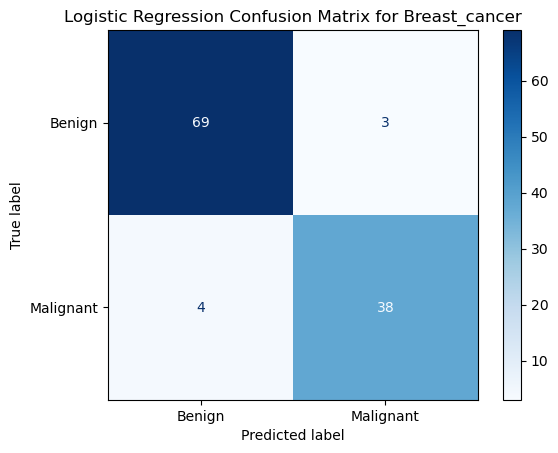

In [22]:
# Visualizing the Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
LR_display = ConfusionMatrixDisplay(confusion_matrix(y_test, logistic_prediction), display_labels=["Benign", "Malignant"])
LR_display.plot(cmap=plt.cm.Blues)
plt.title("Logistic Regression Confusion Matrix for Breast_cancer")
plt.savefig("images/LR_confusion_matrix.png", bbox_inches="tight")
plt.show()

## Hyperparameter Tuning

In [23]:
logistic_params = ({
    "C": [0.01, 0.1, 1, 10, 100],
    "max_iter":[100, 200, 500],
    "solver":["liblinear", "lbfgs"]
})
logistic_grid = GridSearchCV(
    LogisticRegression(random_state=40),
    logistic_params,
    cv=5,
    scoring="accuracy"
)
logistic_grid.fit(X_train_scaled, y_train)

,estimator,LogisticRegre...ndom_state=40)
,param_grid,"{'C': [0.01, 0.1, ...], 'max_iter': [100, 200, ...], 'solver': ['liblinear', 'lbfgs']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [24]:
print(logistic_grid.best_params_)
print(logistic_grid.best_score_)

{'C': 0.1, 'max_iter': 100, 'solver': 'liblinear'}
0.9868131868131869


In [25]:
best_logistic_model = logistic_grid.best_estimator_

logistic_tuned_pred = logistic_grid.predict(X_test_scaled)

best_accuracy = accuracy_score(
    y_test,
    logistic_tuned_pred
)
print("Best Logistic Accuracy", best_accuracy)

Best Logistic Accuracy 0.956140350877193


In [26]:
print(classification_report(y_test, logistic_tuned_pred))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [27]:
confusion_matrix(y_test, logistic_tuned_pred)

array([[71,  1],
       [ 4, 38]])

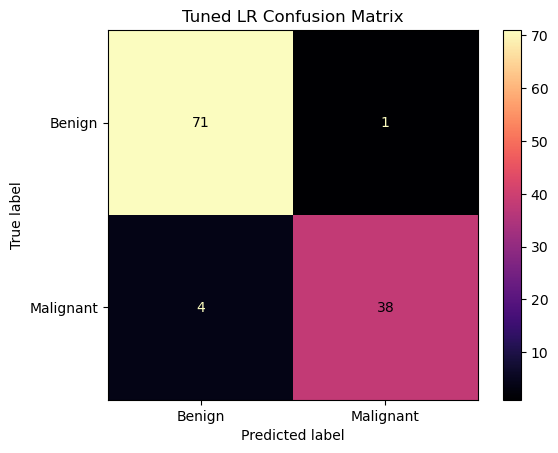

In [61]:
tuned_lr_display = ConfusionMatrixDisplay(confusion_matrix(y_test, logistic_tuned_pred), display_labels=["Benign", "Malignant"])
tuned_lr_display.plot(cmap=plt.cm.magma)
plt.title("Tuned LR Confusion Matrix")
plt.savefig("images/tuned_LR_confusion_matrix.png", bbox_inches="tight")
plt.show()

## DecisionTreeClassifier

In [63]:
tree_model = DecisionTreeClassifier(random_state=40)

tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,40
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [64]:
tree_prediction = tree_model.predict(X_test)

tree_accuracy = accuracy_score(
    y_test,
    tree_prediction
)
print("Decision Tree Accuracy", tree_accuracy)

Decision Tree Accuracy 0.9035087719298246


In [31]:
print(classification_report(y_test, tree_prediction))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92        72
           1       0.86      0.88      0.87        42

    accuracy                           0.90       114
   macro avg       0.90      0.90      0.90       114
weighted avg       0.90      0.90      0.90       114



In [32]:
# Confusion Matrix

confusion_matrix(y_test, tree_prediction)

array([[66,  6],
       [ 5, 37]])

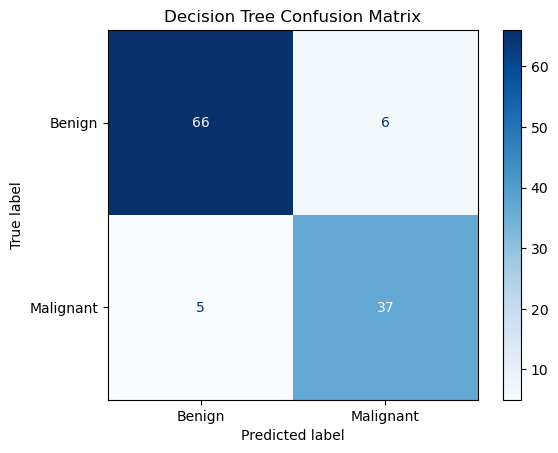

In [33]:
tree_display = ConfusionMatrixDisplay(confusion_matrix(y_test, tree_prediction), display_labels=['Benign', 'Malignant'])
tree_display.plot(cmap=plt.cm.Blues)
plt.title("Decision Tree Confusion Matrix")
plt.show()

## Hyperparameter Tuning

In [65]:
tree_params = ({
    "max_depth":[None, 3, 5, 7, 9],
    "criterion":["gini", "entropy"],
    "min_samples_leaf": [1, 2, 5],
    "min_samples_split": [2, 5, 10]
})
tree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=40),
    tree_params,
    cv=5,
    scoring="accuracy"
)
tree_grid.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=40)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [66]:
print(tree_grid.best_params_)
print(tree_grid.best_score_)

{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
0.9494505494505494


In [67]:
best_tree_model = tree_grid.best_estimator_

tuned_tree_pred = tree_grid.predict(X_test)

tuned_tree_accuracy = accuracy_score(
    y_test,
    tuned_tree_pred
)
print("Tuned DT Accuracy", tuned_tree_accuracy)

Tuned DT Accuracy 0.8947368421052632


In [37]:
print(classification_report(y_test, tuned_tree_pred))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92        72
           1       0.86      0.86      0.86        42

    accuracy                           0.89       114
   macro avg       0.89      0.89      0.89       114
weighted avg       0.89      0.89      0.89       114



In [38]:
confusion_matrix(y_test, tuned_tree_pred)

array([[66,  6],
       [ 6, 36]])

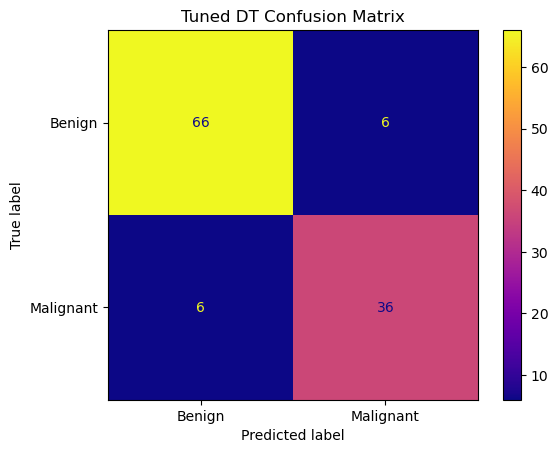

In [39]:
tuned_dt_display = ConfusionMatrixDisplay(confusion_matrix(y_test, tuned_tree_pred), display_labels=["Benign", "Malignant"])
tuned_dt_display.plot(cmap=plt.cm.plasma)
plt.title("Tuned DT Confusion Matrix")
plt.show()

## RandomForestClassifier

In [40]:
forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=40
)
forest_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
forest_pred = forest_model.predict(X_test)

forest_accuracy = accuracy_score(
    y_test,
    forest_pred
)
print("Ramdom Forest Accuracy", forest_accuracy)

Ramdom Forest Accuracy 0.9385964912280702


In [42]:
print(classification_report(y_test, forest_pred))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95        72
           1       0.91      0.93      0.92        42

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



In [43]:
# Confusion Matrix

confusion_matrix(y_test, forest_pred)

array([[68,  4],
       [ 3, 39]])

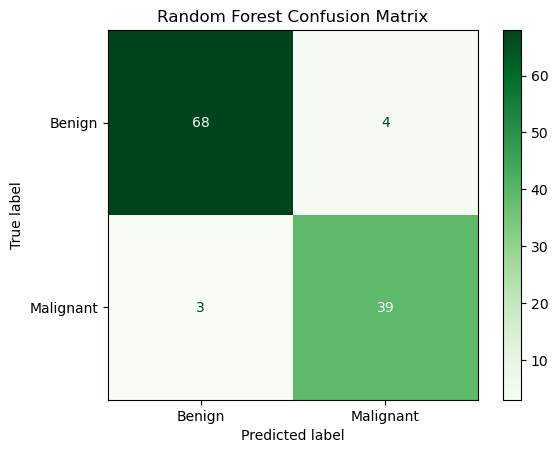

In [44]:
forest_display = ConfusionMatrixDisplay(confusion_matrix(y_test, forest_pred), display_labels=["Benign", "Malignant"])
forest_display.plot(cmap=plt.cm.Greens)
plt.title("Random Forest Confusion Matrix")
plt.savefig("images/forest_confusion_matrix.png", bbox_inches="tight")
plt.show()

## Hyperparameter Tuning

In [45]:
forest_params = ({
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
})
forest_grid = GridSearchCV(
    RandomForestClassifier(random_state=40),
    forest_params,
    cv=5,
    scoring="accuracy"
)
forest_grid.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=40)
,param_grid,"{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [46]:
print(forest_grid.best_params_)
print(forest_grid.best_score_)

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
0.9648351648351647


In [47]:
best_forest_model = forest_grid.best_estimator_

tuned_forest_pred = best_forest_model.predict(X_test)

tuned_forest_accuracy = accuracy_score(
    y_test,
    tuned_forest_pred
)
print("Tuned Random Accuracy", tuned_forest_accuracy)

Tuned Random Accuracy 0.9298245614035088


In [48]:
print(classification_report(y_test, tuned_forest_pred))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        72
           1       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [49]:
confusion_matrix(y_test, tuned_forest_pred)

array([[68,  4],
       [ 4, 38]])

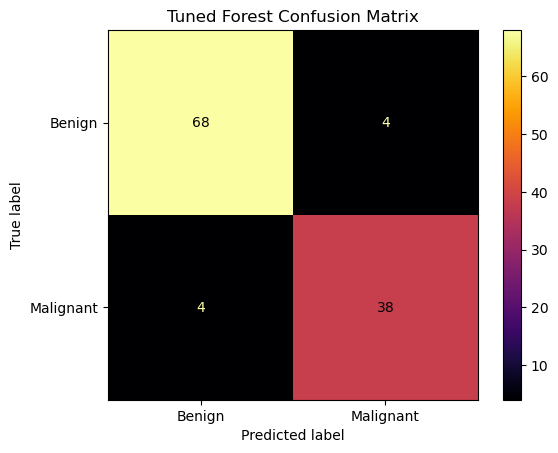

In [50]:
tuned_forest_display = ConfusionMatrixDisplay(confusion_matrix(y_test, tuned_forest_pred), display_labels=["Benign", "Malignant"])
tuned_forest_display.plot(cmap=plt.cm.inferno)
plt.title("Tuned Forest Confusion Matrix")
plt.savefig("images/tuned_forest_confusion_matrix.png", bbox_inches="tight")
plt.show()

## Support Vector Machine

In [51]:
svm_model = SVC()

svm_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [52]:
svm_prediction = svm_model.predict(X_test_scaled)

svm_accuracy = accuracy_score(
    y_test,
    svm_prediction
)

print("SVM Accuracy", svm_accuracy)

print(classification_report(
    y_test,
    svm_prediction
))

SVM Accuracy 0.9385964912280702
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        72
           1       0.91      0.93      0.92        42

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



In [53]:
# Confusion Matrix
confusion_matrix(y_test, svm_prediction)

array([[68,  4],
       [ 3, 39]])

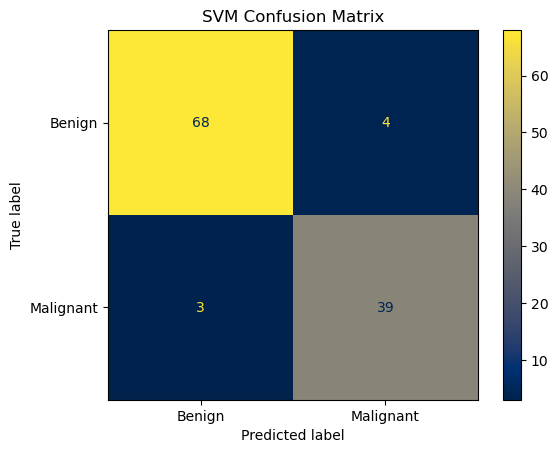

In [54]:
svm_display = ConfusionMatrixDisplay(confusion_matrix(y_test, svm_prediction), display_labels=["Benign", "Malignant"])
svm_display.plot(cmap=plt.cm.cividis)
plt.title("SVM Confusion Matrix")
plt.show()

## Hyperparameter Tuning

In [55]:
svm_params = ({
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto"],
    "kernel": ["linear", "rbf"]
})
svm_grid = GridSearchCV(
    SVC(),
    svm_params,
    cv=5,
    scoring="accuracy"
)
svm_grid.fit(X_train_scaled, y_train)

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [56]:
print(svm_grid.best_params_)
print(svm_grid.best_score_)

{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
0.9824175824175825


In [57]:
svm_best_model = svm_grid.best_estimator_

svm_tuned_prediction = svm_best_model.predict(X_test_scaled)

print("Tuned SVM Accuracy:", accuracy_score(y_test, svm_tuned_prediction))

Tuned SVM Accuracy: 0.9385964912280702


In [58]:
print(classification_report(
    y_test,
    svm_tuned_prediction
))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95        72
           1       0.91      0.93      0.92        42

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



In [59]:
print(confusion_matrix(
    y_test,
    svm_tuned_prediction
))

[[68  4]
 [ 3 39]]


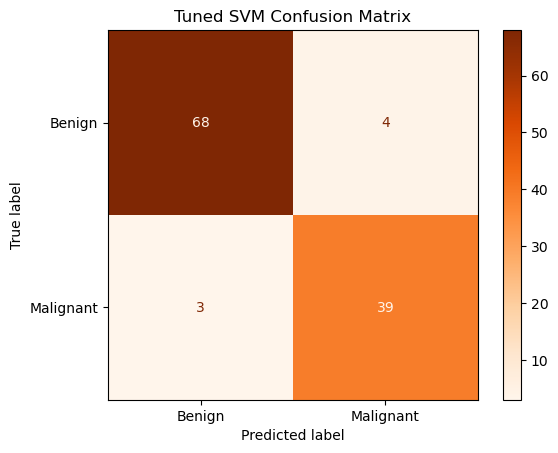

In [69]:
tuned_svm_display = ConfusionMatrixDisplay(confusion_matrix(y_test, svm_tuned_prediction), display_labels=["Benign", "Malignant"])
tuned_svm_display.plot(cmap=plt.cm.Oranges)
plt.title("Tuned SVM Confusion Matrix")
plt.savefig("images/confusion_SVM_matrix.png", bbox_inches="tight")
plt.show()

## Comparing the models

In [68]:
# Let's compare out Models
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "SVM"],
    "Accuracy": [
        best_accuracy * 100,
        tuned_tree_accuracy * 100,
        tuned_forest_accuracy * 100,
        accuracy_score(y_test, svm_tuned_prediction) * 100
    ]
})
results.round(2)

,Model,Accuracy
0,Logistic Regression,95.61
1,Decision Tree,89.47
2,Random Forest,92.98
3,SVM,93.86
